## Tutorial: Inference with DINGO-T1
This tutorial illustrates how to perform inference on the event GW190701_20336 with different detector configurations (H vs. HL. vs HLV) and visualize the resulting posterior distributions.
While 100,000 posterior samples were drawn for the results shown in the paper, we only generate 10,000 samples in this tutorial to speed up inference. This can be easily adjusted in the settings files.

### 0. Installation for Google Colab
If you are running this notebook in Google Colab, you first need to change the runtime to an older python version (`python<=3.12.6`), by clicking `Runtime -> Change runtime type -> Runtime version: 2025.05`.
Then, you can install the correct branch from the `dingo-gw` repository by running the next cell.
If you have already installed an environment locally, comment out the following cell:

In [ ]:
%%capture
# Clone the repository
!git clone --branch dingo-t1 https://github.com/dingo-gw/dingo.git

# Install dingo
%cd dingo
!pip install -e .
%cd ..

Import all required packages

In [1]:
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import requests
# Suppress lal warning
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

from dingo.gw.result import Result
from dingo.core.utils.plotting import plot_corner_multi

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [1]:
from pathlib import Path

from dingo.core.utils.backward_compatibility import torch_load_with_fallback

model_path = Path("dingo_t1.pt")
checkpoint, load_device = torch_load_with_fallback(
    str(model_path),
    preferred_map_location="meta",
)

train_settings = checkpoint["metadata"]["train_settings"]
data_settings = train_settings["data"]
model_settings = train_settings["model"]

print("Model file:", model_path.resolve())
print("Checkpoint version:", checkpoint["version"])
print("Metadata load device:", load_device)
print("Detectors:", data_settings["detectors"])
print("Inference parameters:", len(data_settings["inference_parameters"]))
print("Token size:", data_settings["tokenization"]["token_size"])
print("Posterior model:", model_settings["posterior_model_type"])
print("Embedding type:", model_settings["embedding_type"])
print(
    "Transformer settings:",
    model_settings["embedding_kwargs"]["transformer_kwargs"],
)
print(
    "Context dimension:",
    model_settings["embedding_kwargs"]["final_net_kwargs"]["output_dim"],
)
print("Flow steps:", model_settings["posterior_kwargs"]["num_flow_steps"])

/home/howto/dingo-t1-venv/lib/python3.12/site-packages/dingo/core/utils/backward_compatibility.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(filename, map_

Model file: /mnt/d/AST/06_DINGO_T1_Case_Study/baseline/dingo_t1.pt
Checkpoint version: dingo=0.9.1.dev475+g2b4b9be96
Metadata load device: meta
Detectors: ['H1', 'L1', 'V1']
Inference parameters: 14
Token size: 16
Posterior model: normalizing_flow
Embedding type: transformer
Transformer settings: {'d_model': 1024, 'dim_feedforward': 2048, 'nhead': 16, 'dropout': 0.0, 'num_layers': 8, 'norm_first': True}
Context dimension: 128
Flow steps: 30


The goal of this tutorial is to produce a plot which will look similar to this:

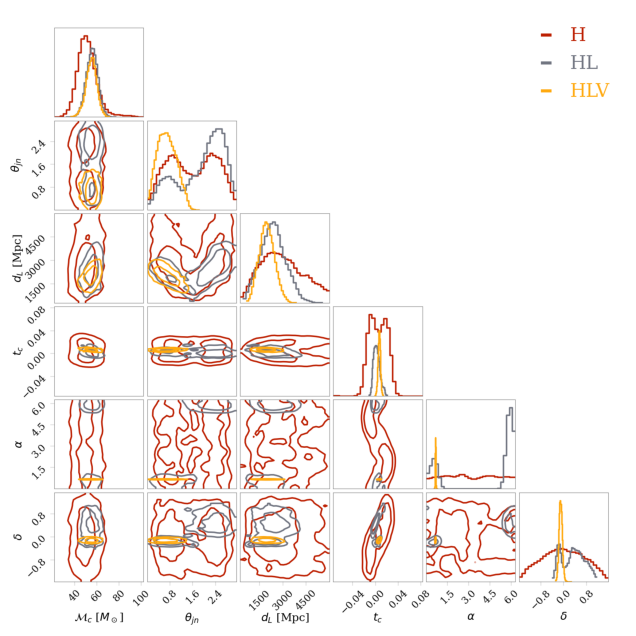

In [2]:
local_path = "../00_figures/corner_plot_comparison_GW190701_203306_H_vs_HL_vs_HLV.png"
github_url = "https://raw.githubusercontent.com/dingo-gw/dingo-T1/main/00_figures/corner_plot_comparison_GW190701_203306_H_vs_HL_vs_HLV.png"

# Try to load locally
if os.path.exists(local_path):
    img = Image.open(local_path)
else:
    # Load from GitHub (for Colab)
    response = requests.get(github_url)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off");

### 1. Download model from Zenodo
As a first step, we have to download the DINGO-T1 model from [Zenodo](https://zenodo.org/records/17726076) via:

In [ ]:
%pwd # If you run it locally: Check that the model is saved into the folder /02_inference_with_pretrained_models, you might need to adjust the path.

In [ ]:
#%cd dingo-T1/02_inference_with_pretrained_model # Optional: Adjust the path
!wget -O dingo_t1.pt "https://zenodo.org/records/17726076/files/dingo_t1.pt?download=1"

### 2. Run inference with `dingo_pipe`
For Google Colab, we need to download the `.ini` files to the directory `/events/GW190701_203306`:

In [ ]:
ini_files = ["events/GW190701_203306/H1/GW190701_203306.ini", "events/GW190701_203306/H1_L1/GW190701_203306.ini", "events/GW190701_203306/H1_L1_V1/GW190701_203306.ini"]
base_url = "https://raw.githubusercontent.com/dingo-gw/dingo-T1/main/02_inference_with_pretrained_model"
if not os.path.exists(ini_files[0]):
    # Remove automatically created Colab folder
    if os.path.isdir("sample_data"):
        os.system("rm -rf sample_data")
    for file_path in ini_files:
        parent_dir = os.path.dirname(file_path)
        os.makedirs(parent_dir, exist_ok=True)

        github_url = base_url + file_path
        print(f"Downloading {file_path}...")
        response = requests.get(github_url)
        response.raise_for_status()
        with open(file_path, "wb") as f:
            f.write(response.content)
    print("All files downloaded")
else:
    print("Files already exist locally")

Now, we can run `dingo_pipe` via:

In [3]:
!dingo_pipe events/GW190701_203306/H1/GW190701_203306.ini

10:32 dingo_pipe INFO    : Loading dingo model from dingo_t1.pt in order to access settings.
/home/howto/dingo-t1-venv/lib/python3.12/site-packages/dingo/core/utils/backward_compatibility.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an iss

### Plot bug

In [4]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.3.5
Pandas: 3.0.5


Depending on the directory where the jupyter server was started, you might need to adjust your path in the `.ini` files and when loading the result.

In [1]:
import pandas as pd

print("Pandas:", pd.__version__)

Pandas: 2.3.3


In [2]:
from pathlib import Path
from dingo.gw.result import Result

result_file_h = Path(
    "events/GW190701_203306/H1/result/"
    "GW190701_203306_data0_1246048404-56_importance_sampling.hdf5"
)

print("Result exists:", result_file_h.exists())
print("Result size (MiB):", round(result_file_h.stat().st_size / 1024**2, 1))

result_h = Result(file_name=str(result_file_h))
result_h.print_summary()

/home/howto/dingo-t1-venv/lib/python3.12/site-packages/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Result exists: True
Result size (MiB): 1.3
Loading dataset from events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Number of samples: 10000
Log(evidence): -2922.496 +- 0.022
Effective samples 1712.3: (Sample efficiency = 17.12%)


In [3]:
!dingo_pipe_plot \
    --label GW190701_203306_data0_1246048404-56_importance_sampling_plot \
    --result events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5 \
    --outdir events/GW190701_203306/H1/result \
    --corner \
    --weights \
    --log_probs

10:53 dingo_pipe INFO    : Generating plots for results file events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5
Loading dataset from events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
10:53 dingo_pipe INFO    : Generating corner plot.
10:53 dingo_pipe INFO    : Generating weights plot.
10:53 dingo_pipe INFO    : Generating log probability plot.


Number of plots: 2

GW190701_203306_data0_1246048404-56_importance_sampling_plot_log_probs.png


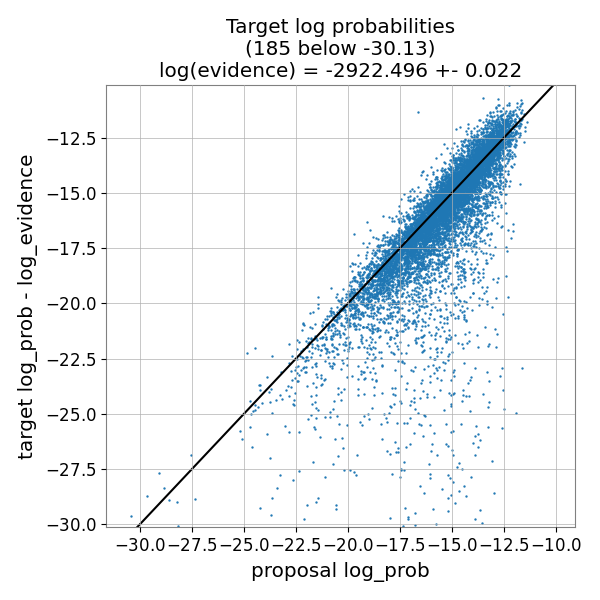


GW190701_203306_data0_1246048404-56_importance_sampling_plot_weights.png


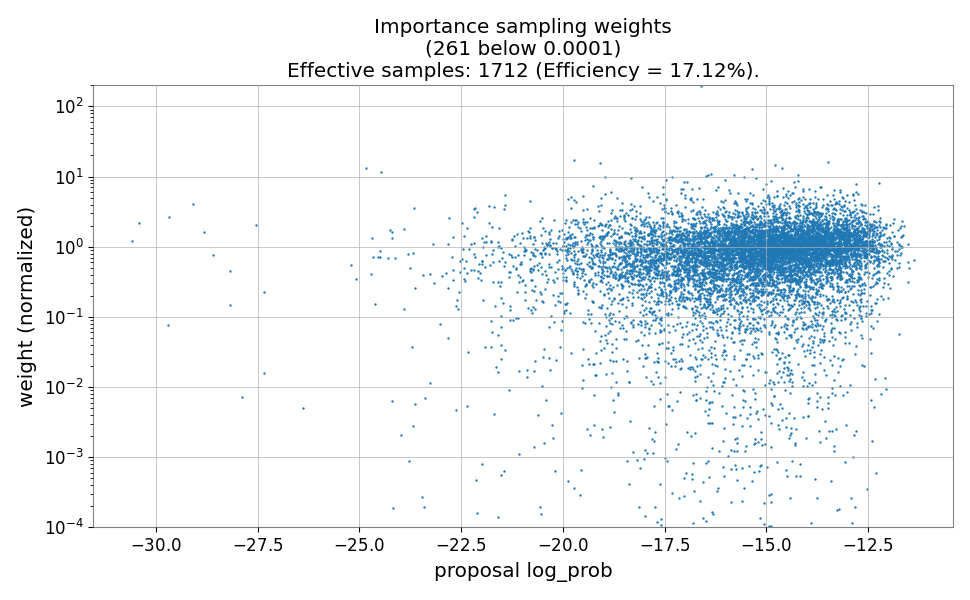

In [4]:
from pathlib import Path
from IPython.display import Image, display

plot_dir_h = Path("events/GW190701_203306/H1/result")
plot_files_h = sorted(plot_dir_h.glob("*importance_sampling_plot*.png"))

print("Number of plots:", len(plot_files_h))

for plot_file in plot_files_h:
    print(f"\n{plot_file.name}")
    display(Image(filename=str(plot_file)))

In [5]:
result_h = Result(file_name="events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5")
result_h.print_summary()

Loading dataset from events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Number of samples: 10000
Log(evidence): -2922.496 +- 0.022
Effective samples 1712.3: (Sample efficiency = 17.12%)


As expected, we obtain a high sample efficiency, since this is a single-detector event with a broad posterior distribution which makes it easier to learn for DINGO-T1. The exact value might deviate from the ones reported in the paper since we do not draw enough samples to obtain a valid estimate and the efficiency will display a certain randomness.

Since we want to compare posteriors across detector configurations, we will run dingo_pipe for HL and HLV as well:

In [7]:
import sys

!{sys.executable} -m pip install "gwpy==3.0.13"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.3 MB/s eta 0:00:00a 0:00:01m
  Attempting uninstall: gwpy
    Found existing installation: gwpy 4.0.2
    Uninstalling gwpy-4.0.2:
      Successfully uninstalled gwpy-4.0.2


In [1]:
!dingo_pipe events/GW190701_203306/H1_L1/GW190701_203306.ini

11:48 dingo_pipe INFO    : Loading dingo model from dingo_t1.pt in order to access settings.
/home/howto/dingo-t1-venv/lib/python3.12/site-packages/dingo/core/utils/backward_compatibility.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an iss

In [2]:
from dingo.gw.result import Result

result_h = Result(
    file_name=(
        "events/GW190701_203306/H1/result/"
        "GW190701_203306_data0_1246048404-56_importance_sampling.hdf5"
    )
)

result_hl = Result(
    file_name=(
        "events/GW190701_203306/H1_L1/result/"
        "GW190701_203306_data0_1246048404-56_importance_sampling.hdf5"
    )
)

print("===== H1 =====")
result_h.print_summary()

print("\n===== H1 + L1 =====")
result_hl.print_summary()

/home/howto/dingo-t1-venv/lib/python3.12/site-packages/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Loading dataset from events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Loading dataset from events/GW190701_203306/H1_L1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
===== H1 =====
Number of samples: 10000
Log(evidence): -2922.496 +- 0.022
Effective samples 1712.3: (Sample efficiency = 17.12%)

===== H1 + L1 =====
Number of samples: 10000
Log(evidence): -5655.027 +- 0.021
Effective samples 1903.4: (Sample efficiency = 19.03%)


Number of H1_L1 plots: 2

GW190701_203306_data0_1246048404-56_importance_sampling_plot_log_probs.png


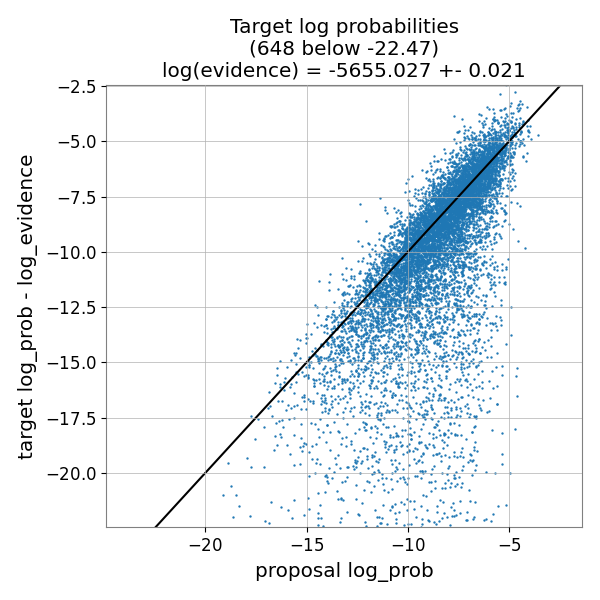


GW190701_203306_data0_1246048404-56_importance_sampling_plot_weights.png


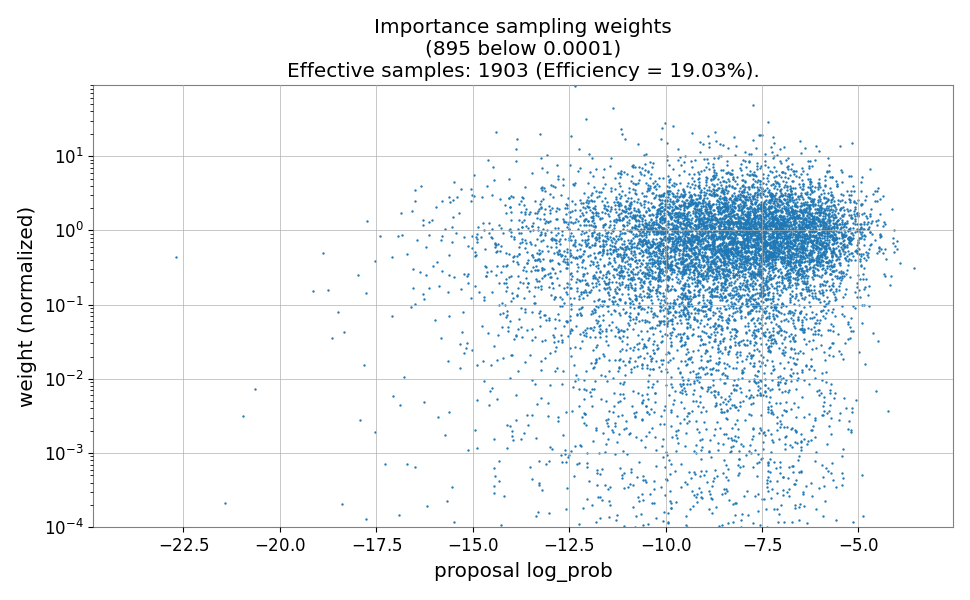

In [3]:
from pathlib import Path
from IPython.display import Image, display

plot_dir_hl = Path("events/GW190701_203306/H1_L1/result")
plot_files_hl = sorted(
    plot_dir_hl.glob("*importance_sampling_plot*.png")
)

print("Number of H1_L1 plots:", len(plot_files_hl))

for plot_file in plot_files_hl:
    print(f"\n{plot_file.name}")
    display(Image(filename=str(plot_file)))

In [4]:
!dingo_pipe events/GW190701_203306/H1_L1_V1/GW190701_203306.ini

13:12 dingo_pipe INFO    : Loading dingo model from dingo_t1.pt in order to access settings.
/home/howto/dingo-t1-venv/lib/python3.12/site-packages/dingo/core/utils/backward_compatibility.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an iss

In [5]:
import numpy as np

from dingo.gw.result import Result
from dingo.core.utils.plotting import plot_corner_multi

result_h = Result(
    file_name=(
        "events/GW190701_203306/H1/result/"
        "GW190701_203306_data0_1246048404-56_importance_sampling.hdf5"
    )
)

result_hl = Result(
    file_name=(
        "events/GW190701_203306/H1_L1/result/"
        "GW190701_203306_data0_1246048404-56_importance_sampling.hdf5"
    )
)

result_hlv = Result(
    file_name=(
        "events/GW190701_203306/H1_L1_V1/result/"
        "GW190701_203306_data0_1246048404-56_importance_sampling.hdf5"
    )
)

print("H:")
result_h.print_summary()

print("\nHL:")
result_hl.print_summary()

print("\nHLV:")
result_hlv.print_summary()

Loading dataset from events/GW190701_203306/H1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Loading dataset from events/GW190701_203306/H1_L1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Loading dataset from events/GW190701_203306/H1_L1_V1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
H:
Number of samples: 10000
Log(evidence): -2922.496 +- 0.022
Effective samples 1712.3: (Sample efficiency = 17.12%)

HL:
Number of samples: 10000
Log(evidence): -5655.027 +- 0.021
Effective samples 1903.4: (Sample efficiency = 19.03%)

HLV:
Number of samples: 10000
Log(evidence): -8506.779 +- 0.023
Effective samples 1642.1: (Sample efficiency = 16.42%)


In [6]:
h_samples = result_h.get_pesummary_samples()
hl_samples = result_hl.get_pesummary_samples()
hlv_samples = result_hlv.get_pesummary_samples()

event_times = [
    result_h.event_metadata["time_event"],
    result_hl.event_metadata["time_event"],
    result_hlv.event_metadata["time_event"],
]

assert np.unique(event_times).size == 1

h_samples["geocent_time"] -= event_times[0]
hl_samples["geocent_time"] -= event_times[0]
hlv_samples["geocent_time"] -= event_times[0]

print("H samples:", len(h_samples))
print("HL samples:", len(hl_samples))
print("HLV samples:", len(hlv_samples))
print("Common trigger time:", event_times[0])

H samples: 10000
HL samples: 10000
HLV samples: 10000
Common trigger time: 1246048404.56


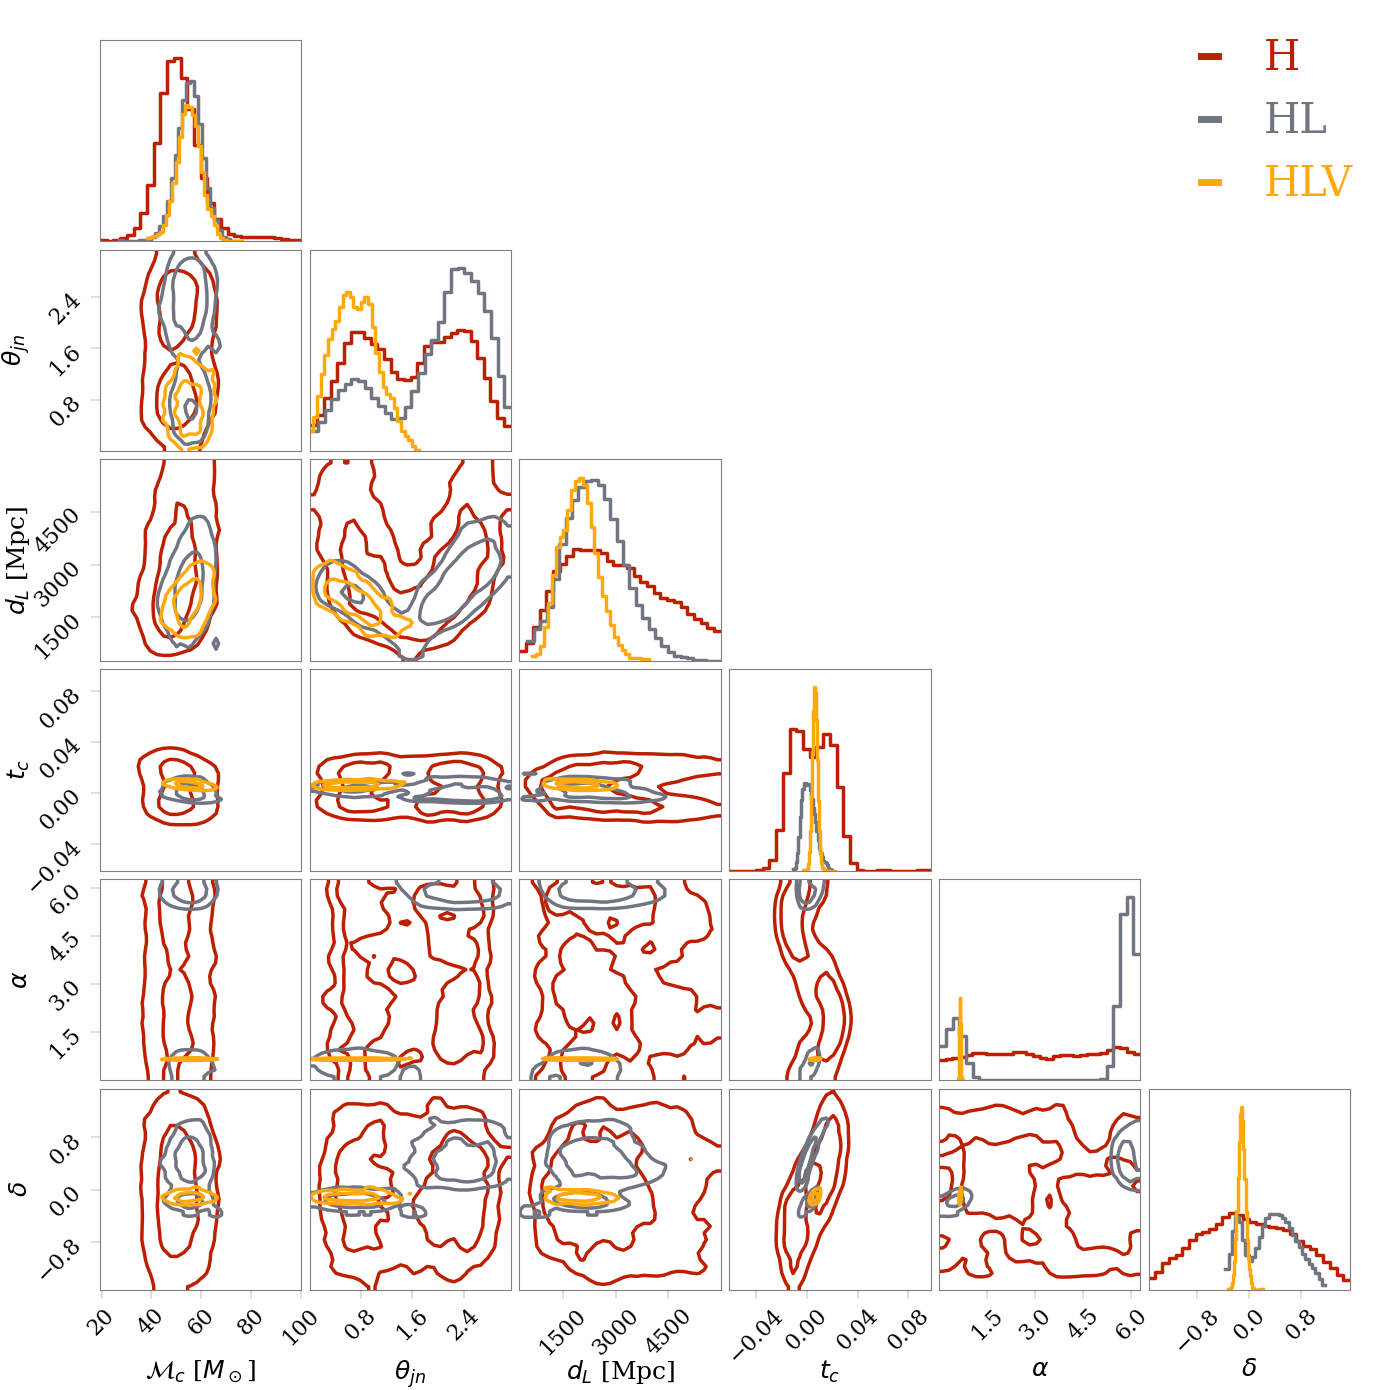

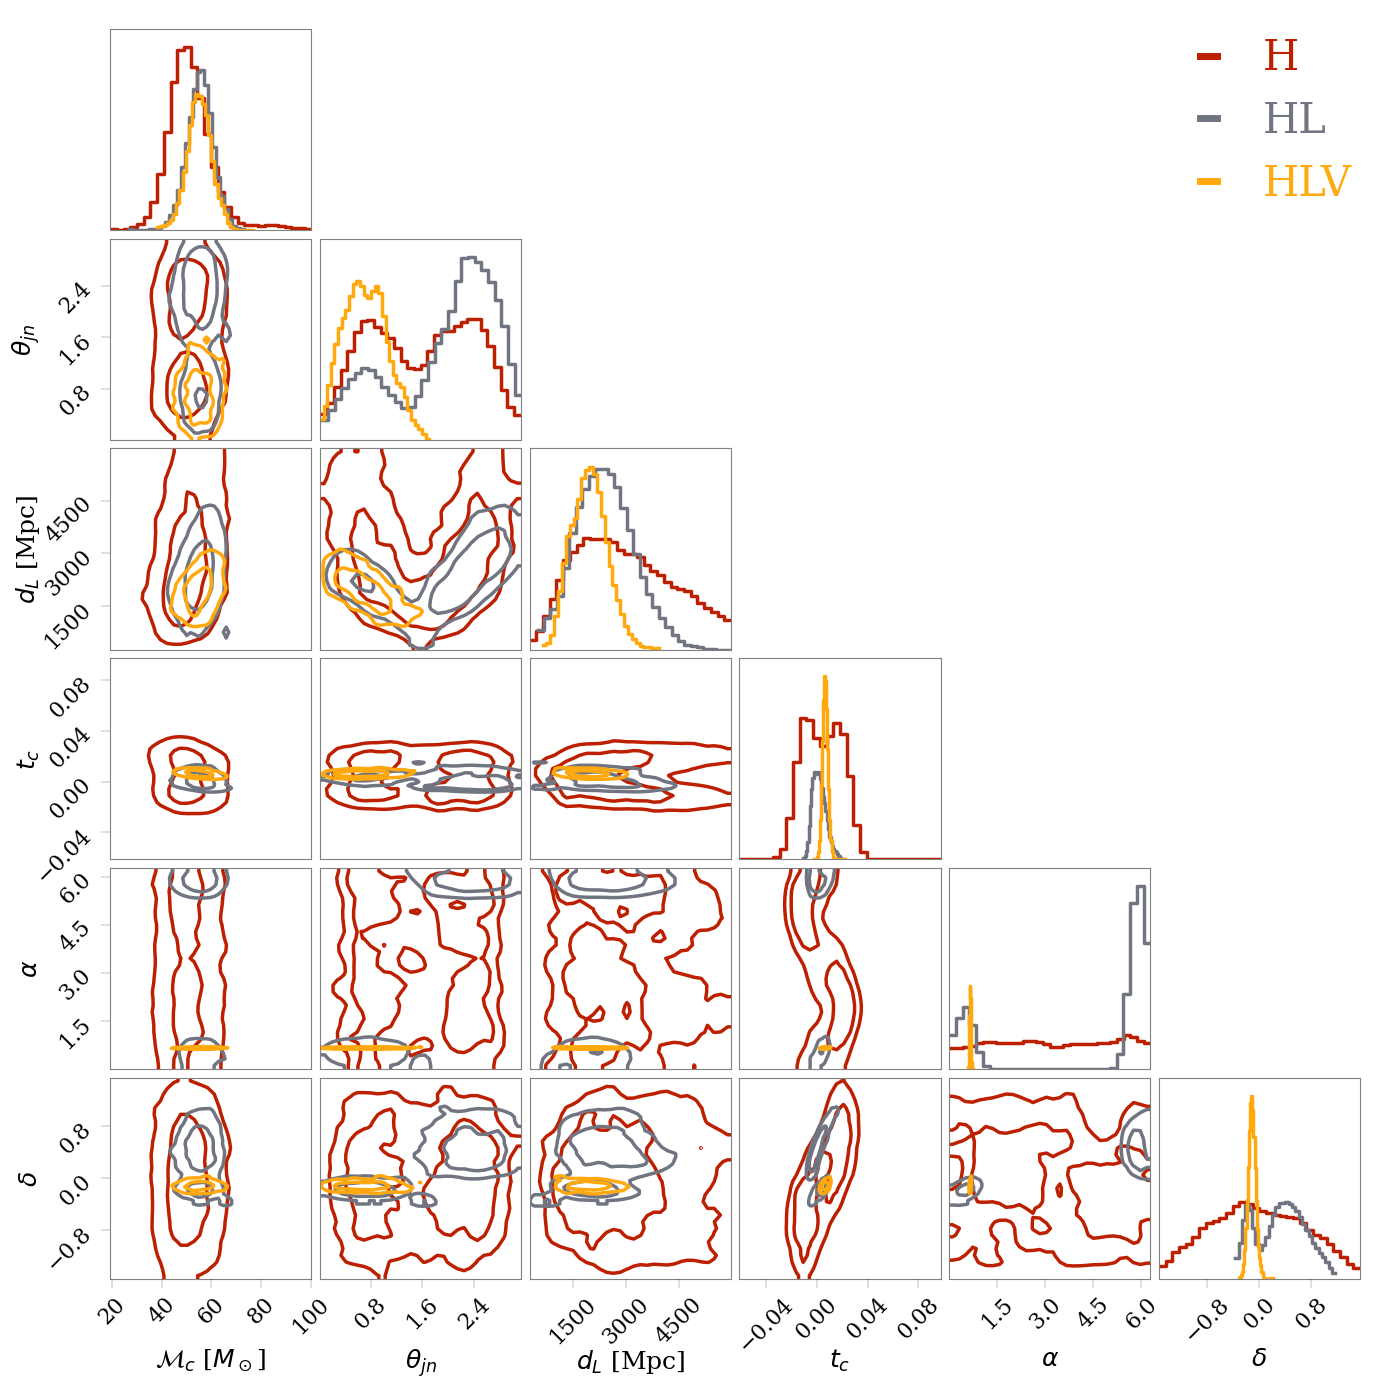

In [7]:
from IPython.display import Image, display

latex_labels_dict = {
    "chirp_mass": r"$\mathcal{M}_c$ [$M_\odot$]",
    "theta_jn": r"$\theta_{jn}$",
    "luminosity_distance": r"$d_L$ [Mpc]",
    "geocent_time": r"$t_c$",
    "ra": r"$\alpha$",
    "dec": r"$\delta$",
}

params = list(latex_labels_dict.keys())
colors = ["#bd1f01", "#717581", "#ffa90e"]

out_file_name = (
    "corner_plot_comparison_GW190701_203306_H_vs_HL_vs_HLV.png"
)

kwargs = {
    "legend_kwargs": {
        "fontsize": 30,
        "frameon": False,
    },
    "label_kwargs": {
        "fontsize": 18,
    },
    "labelpad": 0.04,
}

fig = plot_corner_multi(
    [
        h_samples[params],
        hl_samples[params],
        hlv_samples[params],
    ],
    weights=[None, None, None],
    labels=["H", "HL", "HLV"],
    filename=out_file_name,
    latex_labels_dict=latex_labels_dict,
    colors=colors,
    **kwargs,
)

display(Image(filename=out_file_name))

In [14]:
import numpy as np
import pandas as pd

sample_sets = {
    "H": h_samples,
    "HL": hl_samples,
    "HLV": hlv_samples,
}

parameters = {
    "chirp_mass": "chirp_mass [M_sun]",
    "theta_jn": "theta_jn [rad]",
    "luminosity_distance": "distance [Mpc]",
    "geocent_time": "t_c [s]",
    "dec": "dec [rad]",
}

summary_rows = []

for configuration, samples in sample_sets.items():
    for parameter, label in parameters.items():
        values = samples[parameter].to_numpy(dtype=float)
        q05, q50, q95 = np.quantile(values, [0.05, 0.50, 0.95])

        summary_rows.append(
            {
                "Configuration": configuration,
                "Parameter": label,
                "Median": q50,
                "5%": q05,
                "95%": q95,
                "90% width": q95 - q05,
            }
        )

credible_intervals = pd.DataFrame(summary_rows)

with pd.option_context("display.max_rows", None, "display.precision", 5):
    display(credible_intervals)

,Configuration,Parameter,Median,5%,95%,90% width
0,H,chirp_mass [M_sun],50.48745,39.81766,65.91834,26.10068
1,H,theta_jn [rad],1.64227,0.36768,2.76523,2.39755
2,H,distance [Mpc],2807.97144,1023.51550,5380.06250,4356.54700
3,H,t_c [s],0.00356,-0.01577,0.02506,0.04083
4,H,dec [rad],-0.05180,-1.17375,1.13690,2.31065
5,HL,chirp_mass [M_sun],55.53046,46.68458,63.50874,16.82416
6,HL,theta_jn [rad],2.17925,0.42572,2.89211,2.46639
7,HL,distance [Mpc],2353.38184,1155.18359,3817.26995,2662.08635
8,HL,t_c [s],0.00122,-0.00530,0.01100,0.01629
9,HL,dec [rad],0.35396,-0.23186,0.92094,1.15280


### 3. Load samples and visualize posterior

In [8]:
result_hl = Result(file_name="events/GW190701_203306/H1_L1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5")
result_hl.print_summary()

Loading dataset from events/GW190701_203306/H1_L1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Number of samples: 10000
Log(evidence): -5655.027 +- 0.021
Effective samples 1903.4: (Sample efficiency = 19.03%)


In [9]:
result_hlv = Result(file_name="events/GW190701_203306/H1_L1_V1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5")
result_hlv.print_summary()

Loading dataset from events/GW190701_203306/H1_L1_V1/result/GW190701_203306_data0_1246048404-56_importance_sampling.hdf5.
Number of samples: 10000
Log(evidence): -8506.779 +- 0.023
Effective samples 1642.1: (Sample efficiency = 16.42%)


In [10]:
h_samples = result_h.get_pesummary_samples()
hl_samples = result_hl.get_pesummary_samples()
hlv_samples = result_hlv.get_pesummary_samples()

# Subtract trigger time
event_times = [result_h.event_metadata["time_event"], result_hl.event_metadata["time_event"], result_hlv.event_metadata["time_event"]]
assert np.unique(event_times).size == 1
h_samples["geocent_time"] -= event_times[0]
hl_samples["geocent_time"] -= event_times[0]
hlv_samples["geocent_time"] -= event_times[0]

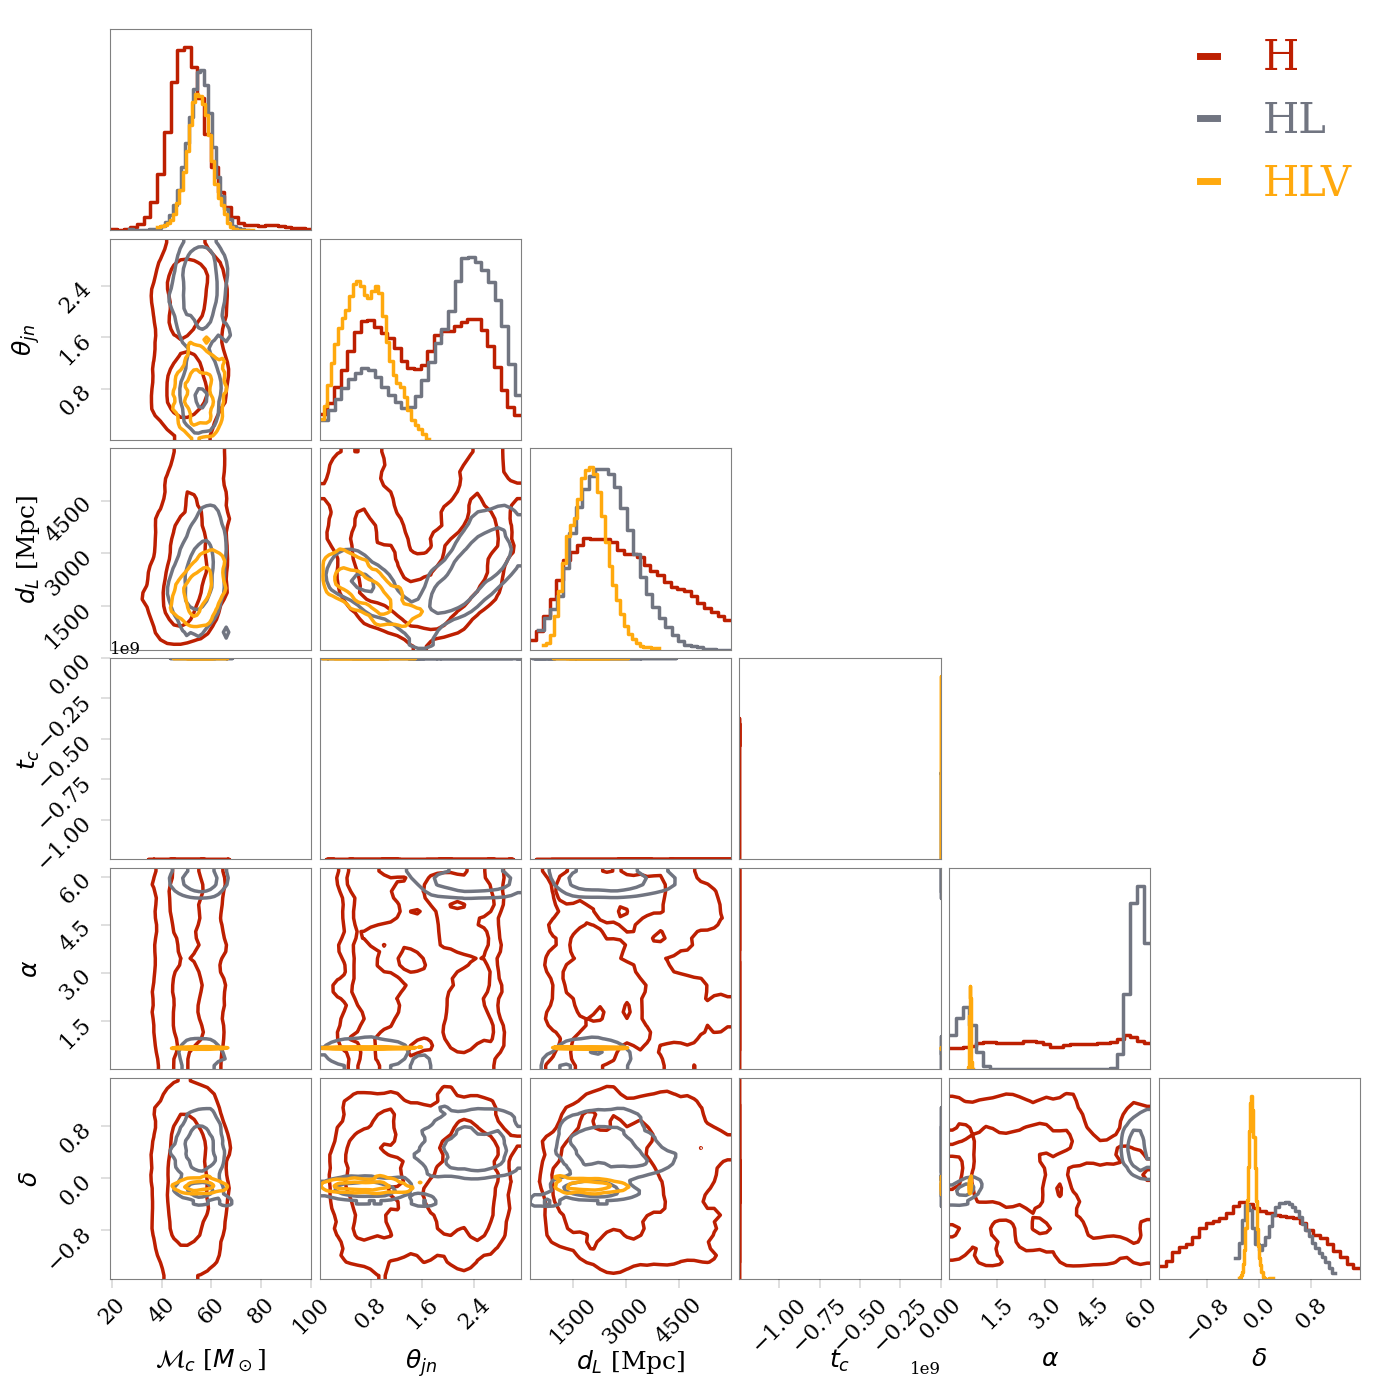

In [11]:
latex_labels_dict = {"chirp_mass": r"$\mathcal{M}_c$ [$M_\odot$]", "theta_jn": r"$\theta_{jn}$", "luminosity_distance": r"$d_L$ [Mpc]", "geocent_time": r"$t_c$", "ra": r"$\alpha$", "dec": r"$\delta$"}
params = list(latex_labels_dict.keys())
colors = ['#bd1f01', '#717581', '#ffa90e']

# Filename of the corner plot
out_file_name = "corner_plot_comparison_GW190701_203306_H_vs_HL_vs_HLV.png"
kwargs = {"legend_kwargs": {"fontsize": 30, "frameon": False},
          "label_kwargs": {"fontsize": 18},
         "labelpad": 0.04,
}

fig = plot_corner_multi(
    [h_samples[params], hl_samples[params], hlv_samples[params]],
    weights=[None, None, None],
    labels=["H", "HL", "HLV"],
    filename=out_file_name,
    latex_labels_dict=latex_labels_dict,
    colors=colors,
    **kwargs,
)

If you want to experiment further by changing the frequency ranges, you can do so my modifying:

**(1) Minimum frequency**:

`minimum-frequency = 50.0` (for all detectors) or `minimum-frequency = {'H1': 30, 'L1': 50, 'V1': 20}` (for individual detectors) (model trained with masking up to $f_\mathrm{min} = 180$Hz)

**(2) Maximum frequency**:

`maximum-frequency = 224.0` (for all detectors) or `maximum-frequency = {'H1': 224, 'L1': 448, 'V1': 896}` (for individual detectors) (model trained with masking as low as $f_\mathrm{max} = 80$Hz)

**(3) PSD notching**:

`suppress = {'V1': [46, 51]}` (model trained with a maximal suppress range of 10 Hz across the full frequency range of [20, 1810] Hz)